# Content-Based Filtering
### MovieLens 1M -- Hybrid Recommendation Engine
**Author:** Ritikesh

---

## What this notebook covers

| Section | Description |
|---------|-------------|
| 1 | Data loading |
| 2 | Evaluation helpers |
| 3 | Building the movie soup -- combining text features |
| 4 | TF-IDF vectorisation -- turning text into numbers |
| 5 | Movie-movie cosine similarity matrix |
| 6 | Finding similar movies -- `find_similar_movies()` |
| 7 | User taste profile -- aggregating liked movie features |
| 8 | Content-based recommender -- `cb_recommend()` |
| 9 | Evaluation -- Precision@K, Recall@K, NDCG@K |
| 10 | Cold start comparison -- SVD vs content-based |
| 11 | Catalog coverage and diversity analysis |
| 12 | Save everything for the hybrid notebook |

> **Prerequisites:** `setup.ipynb`, `eda.ipynb`, `baseline_matrix.ipynb`, `svd_matrix_factorization.ipynb`
> Saved files must exist in `../models/` and `../data/`


## 1. Data Loading

Import libraries and load all saved data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix, save_npz
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity, linear_kernel
import joblib, time, json, os, re, warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 120, "figure.facecolor": "white",
    "axes.facecolor": "#f8f8f8", "axes.grid": True,
    "grid.color": "white", "grid.linewidth": 1.2,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.family": "DejaVu Sans",
    "axes.titlesize": 13, "axes.titleweight": "bold",
    "axes.labelsize": 11,
})
PALETTE = ["#1F3864", "#1D9E75", "#EF9F27", "#E24B4A", "#7F77DD", "#D4537E"]

print("Imports done")


Imports done


In [2]:
train_df    = pd.read_parquet("../data/train.parquet")
test_df     = pd.read_parquet("../data/test.parquet")
movie_stats = pd.read_parquet("../data/movie_stats.parquet")

movies = pd.read_csv(
    "../data/ml-1m/movies.dat", sep="::", engine="python",
    names=["movie_id", "title", "genres"], encoding="latin-1"
)

all_user_ids  = sorted(train_df["user_id"].unique())
all_movie_ids = sorted(movies["movie_id"].unique())

print("Loaded:")
print(f"  train_df  : {len(train_df):,} ratings")
print(f"  test_df   : {len(test_df):,} ratings")
print(f"  movies    : {len(movies):,}")
print(f"  users     : {len(all_user_ids):,}")
print(f"  movies    : {len(all_movie_ids):,} total in catalogue")


Loaded:
  train_df  : 800,193 ratings
  test_df   : 200,016 ratings
  movies    : 3,883
  users     : 6,040
  movies    : 3,883 total in catalogue


## 2. Evaluation Helpers

Same metrics as before -- defined here for self-containment.

In [3]:
def get_relevant_items(user_id, threshold=4.0):
    return set(test_df.loc[
        (test_df["user_id"] == user_id) & (test_df["rating"] >= threshold),
        "movie_id"
    ])

def precision_at_k(recommended_ids, relevant_ids, k):
    if k == 0:
        return 0.0
    hits = len(set(list(recommended_ids)[:k]) & relevant_ids)
    return hits / k

def recall_at_k(recommended_ids, relevant_ids, k):
    if len(relevant_ids) == 0:
        return 0.0
    hits = len(set(list(recommended_ids)[:k]) & relevant_ids)
    return hits / len(relevant_ids)

def ndcg_at_k(recommended_ids, relevant_ids, k):
    if len(relevant_ids) == 0:
        return 0.0
    recommended_k = list(recommended_ids)[:k]
    dcg  = sum(1.0 / np.log2(i + 2)
               for i, item in enumerate(recommended_k) if item in relevant_ids)
    idcg = sum(1.0 / np.log2(i + 2)
               for i in range(min(k, len(relevant_ids))))
    return dcg / idcg if idcg > 0 else 0.0

def evaluate_model(recommend_fn, user_ids, k=10, sample_size=500, random_state=42):
    np.random.seed(random_state)
    sample_users = np.random.choice(user_ids, size=min(sample_size, len(user_ids)), replace=False)
    precisions, recalls, ndcgs = [], [], []
    for user_id in sample_users:
        relevant = get_relevant_items(user_id)
        if len(relevant) == 0:
            continue
        rec_ids = list(recommend_fn(user_id, n=k)["movie_id"])
        precisions.append(precision_at_k(rec_ids, relevant, k))
        recalls.append(recall_at_k(rec_ids, relevant, k))
        ndcgs.append(ndcg_at_k(rec_ids, relevant, k))
    return {
        "precision@k": float(np.mean(precisions)),
        "recall@k":    float(np.mean(recalls)),
        "ndcg@k":      float(np.mean(ndcgs)),
        "n_users":     len(precisions),
    }

def popularity_recommend(user_id, n=10):
    already_seen = set(train_df.loc[train_df["user_id"] == user_id, "movie_id"])
    recs = (
        movie_stats[~movie_stats["movie_id"].isin(already_seen)]
        .head(n)[["movie_id", "title", "bayesian_avg"]]
        .rename(columns={"bayesian_avg": "score"})
    )
    recs["source"] = "popularity"
    return recs.reset_index(drop=True)

print("Evaluation helpers defined")


Evaluation helpers defined


## 3. Building the Movie Soup

Content-based filtering needs a text description for each movie.
We have two sources of information:

- **Genres** from `movies.dat` (e.g. `Action|Sci-Fi|Thriller`)
- **Year** extracted from the title (e.g. `1999`) -- binned into decades

We combine these into one text string per movie called the **soup**.
The idea is simple: two movies with similar soups should be similar movies.

Later, TF-IDF will convert each soup into a vector of numbers,
and cosine similarity will measure how close any two vectors are.


In [4]:
movies_cb = movies.copy()

# ── Clean genres: replace pipe separator with space, lowercase ────────────────
# Also remove hyphens so 'Film-Noir' becomes 'filmnoir' (one token)
movies_cb["genre_str"] = (
    movies_cb["genres"]
    .str.replace("|", " ", regex=False)
    .str.replace("-", "", regex=False)
    .str.lower()
    .str.strip()
)

# ── Extract year from title and bin into decades ───────────────────────────────
# e.g. 1999 -> "decade1990s", 1984 -> "decade1980s"
def extract_decade(title):
    match = re.search(r"\((\d{4})\)", title)
    if match:
        year = int(match.group(1))
        decade = (year // 10) * 10
        return f"decade{decade}s"
    return ""

movies_cb["decade_str"] = movies_cb["title"].apply(extract_decade)

# ── Combine into final soup (repeat genres 2x to give them more weight) ────────
movies_cb["soup"] = (
    movies_cb["genre_str"] + " "
    + movies_cb["genre_str"] + " "
    + movies_cb["decade_str"]
).str.strip()

# ── Quick inspection ──────────────────────────────────────────────────────────
print("Sample soups:")
print()
for _, row in movies_cb.sample(8, random_state=42).iterrows():
    print(f"  {row['title'][:40]:<40} | {row['soup']}")

print()
print(f"Movies with a soup : {(movies_cb['soup'] != '').sum():,}")
print(f"Movies with decade : {(movies_cb['decade_str'] != '').sum():,}")


Sample soups:

  Ridicule (1996)                          | drama drama decade1990s
  American Pie (1999)                      | comedy comedy decade1990s
  Rent-A-Cop (1988)                        | action comedy action comedy decade1980s
  Fabulous Baker Boys, The (1989)          | drama romance drama romance decade1980s
  Quest for Camelot (1998)                 | adventure animation children's fantasy adventure animation children's fantasy decade1990s
  Downhill (1927)                          | drama drama decade1920s
  Low Life, The (1994)                     | drama drama decade1990s
  Flintstones, The (1994)                  | children's comedy children's comedy decade1990s

Movies with a soup : 3,883
Movies with decade : 3,883


## 4. TF-IDF Vectorisation

TF-IDF converts each movie's soup string into a vector of numbers.

**TF** (term frequency) = how often a word appears in this movie's soup.
**IDF** (inverse document frequency) = how rare that word is across all movies.

The effect: common genres like `drama` that appear everywhere get a low weight.
Rare genres like `filmnoir` or `western` that distinguish a movie get a high weight.
This makes similarity scores much more meaningful than simple word counting.


In [5]:
vectorizer = TfidfVectorizer(
    analyzer    = "word",
    ngram_range = (1, 1),
    min_df      = 2,          # ignore terms that appear in fewer than 2 movies
    sublinear_tf= True,       # apply log normalization to term frequency
)

tfidf_matrix = vectorizer.fit_transform(movies_cb["soup"])
feature_names = vectorizer.get_feature_names_out()

print(f"TF-IDF matrix shape : {tfidf_matrix.shape}")
print(f"  (rows = movies, cols = unique vocab tokens)")
print(f"Vocabulary size     : {len(feature_names)}")
print(f"Matrix density      : {tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]):.2%}")
print()
print(f"Full vocabulary: {sorted(feature_names)}")


TF-IDF matrix shape : (3883, 28)
  (rows = movies, cols = unique vocab tokens)
Vocabulary size     : 28
Matrix density      : 9.47%

Full vocabulary: ['action', 'adventure', 'animation', 'children', 'comedy', 'crime', 'decade1910s', 'decade1920s', 'decade1930s', 'decade1940s', 'decade1950s', 'decade1960s', 'decade1970s', 'decade1980s', 'decade1990s', 'decade2000s', 'documentary', 'drama', 'fantasy', 'filmnoir', 'horror', 'musical', 'mystery', 'romance', 'scifi', 'thriller', 'war', 'western']


In [6]:
# ── Show the TF-IDF vector for a specific movie ───────────────────────────────
def show_movie_vector(title_query):
    mask    = movies_cb["title"].str.contains(title_query, case=False, na=False)
    matches = movies_cb[mask]
    if len(matches) == 0:
        print(f"No movie found matching '{title_query}'")
        return
    row_idx = matches.index[0]
    # iloc in the tfidf_matrix using positional index
    pos_idx   = movies_cb.index.get_loc(row_idx)
    movie_vec = tfidf_matrix[pos_idx]
    title     = matches.iloc[0]["title"]
    soup      = matches.iloc[0]["soup"]

    nonzero_cols = movie_vec.nonzero()[1]
    scores       = movie_vec.data

    vec_df = pd.DataFrame({
        "token": feature_names[nonzero_cols],
        "tfidf": scores,
    }).sort_values("tfidf", ascending=False)

    print(f"Movie  : {title}")
    print(f"Soup   : {soup}")
    print(f"Vector : {len(nonzero_cols)} non-zero tokens")
    print()
    display(vec_df.reset_index(drop=True))

show_movie_vector("Matrix")
print()
show_movie_vector("Toy Story")


Movie  : Matrix, The (1999)
Soup   : action scifi thriller action scifi thriller decade1990s
Vector : 4 non-zero tokens



,token,tfidf
0,scifi,0.636508
1,thriller,0.535717
2,action,0.531859
3,decade1990s,0.158086



Movie  : Toy Story (1995)
Soup   : animation children's comedy animation children's comedy decade1990s
Vector : 4 non-zero tokens



,token,tfidf
0,animation,0.721537
1,children,0.585736
2,comedy,0.340872
3,decade1990s,0.141792


## 5. Movie-Movie Cosine Similarity

With TF-IDF vectors in hand, we compute how similar every pair of movies is.

**Cosine similarity** measures the angle between two vectors.
- Score of 1.0 = vectors point in exactly the same direction = identical profile
- Score of 0.0 = vectors are perpendicular = nothing in common

We do NOT use the angle itself -- we use its cosine, which gives a value between 0 and 1.

The result is a matrix of shape `(n_movies x n_movies)` where
cell `[i, j]` is the similarity score between movie i and movie j.


In [7]:
# ── Build a positional index: movie_id -> row position in tfidf_matrix ────────
# movies_cb may not be 0-indexed after the copy, so we need explicit position lookup
movies_cb = movies_cb.reset_index(drop=True)
movie_id_to_pos = {mid: pos for pos, mid in enumerate(movies_cb["movie_id"])}
pos_to_movie_id = {pos: mid for mid, pos in movie_id_to_pos.items()}

print(f"movies_cb rows          : {len(movies_cb):,}")
print(f"tfidf_matrix rows       : {tfidf_matrix.shape[0]:,}")
print(f"Positional index built  : {len(movie_id_to_pos):,} entries")
print()

# ── Compute full cosine similarity matrix ────────────────────────────────────
# linear_kernel on a normalised TF-IDF matrix == cosine similarity
# and is faster than cosine_similarity() for sparse matrices
print("Computing cosine similarity matrix...")
t0 = time.time()
cosine_sim = linear_kernel(tfidf_matrix, tfidf_matrix)
elapsed = time.time() - t0

print(f"Done in {elapsed:.2f}s")
print(f"Similarity matrix shape : {cosine_sim.shape}")
print(f"Memory                  : {cosine_sim.nbytes / 1e6:.1f} MB")
print()
print("Sample similarity scores:")
print(f"  Matrix (1999) vs Blade Runner (1982)  : checking...")

# Quick check between two known movies
mid_matrix = movies_cb[movies_cb["title"].str.contains("Matrix", na=False)]["movie_id"].values
mid_blade  = movies_cb[movies_cb["title"].str.contains("Blade Runner", na=False)]["movie_id"].values
if len(mid_matrix) > 0 and len(mid_blade) > 0:
    pos_a = movie_id_to_pos[mid_matrix[0]]
    pos_b = movie_id_to_pos[mid_blade[0]]
    score = cosine_sim[pos_a, pos_b]
    print(f"  The Matrix vs Blade Runner            : {score:.4f}")

mid_titanic = movies_cb[movies_cb["title"].str.contains("Titanic", na=False)]["movie_id"].values
if len(mid_matrix) > 0 and len(mid_titanic) > 0:
    pos_a = movie_id_to_pos[mid_matrix[0]]
    pos_b = movie_id_to_pos[mid_titanic[0]]
    score = cosine_sim[pos_a, pos_b]
    print(f"  The Matrix vs Titanic                 : {score:.4f}")
    print()
    print("  (Matrix and Blade Runner should be more similar than Matrix and Titanic)")


movies_cb rows          : 3,883
tfidf_matrix rows       : 3,883
Positional index built  : 3,883 entries

Computing cosine similarity matrix...
Done in 0.21s
Similarity matrix shape : (3883, 3883)
Memory                  : 120.6 MB

Sample similarity scores:
  Matrix (1999) vs Blade Runner (1982)  : checking...
  The Matrix vs Blade Runner            : 0.3420
  The Matrix vs Titanic                 : 0.0382

  (Matrix and Blade Runner should be more similar than Matrix and Titanic)


## 6. Finding Similar Movies

With the similarity matrix built, we can find the most similar movies to any title.

In [8]:
def find_similar_movies(title_query, n=10):
    mask    = movies_cb["title"].str.contains(title_query, case=False, na=False)
    matches = movies_cb[mask]
    if len(matches) == 0:
        print(f"No movie found matching '{title_query}'")
        return None

    movie_id    = matches.iloc[0]["movie_id"]
    movie_title = matches.iloc[0]["title"]
    pos         = movie_id_to_pos[movie_id]

    sim_scores = cosine_sim[pos]

    # Sort all movies by similarity, exclude the query movie itself (score=1.0)
    top_indices = np.argsort(sim_scores)[::-1]
    top_indices = [i for i in top_indices if i != pos][:n]

    results = []
    for idx in top_indices:
        similar_id    = pos_to_movie_id[idx]
        similar_title = movies_cb.iloc[idx]["title"]
        similar_genre = movies_cb.iloc[idx]["genres"]
        results.append({
            "movie_id"   : similar_id,
            "title"      : similar_title,
            "genres"     : similar_genre,
            "similarity" : round(float(sim_scores[idx]), 4),
        })

    result_df = pd.DataFrame(results)
    print(f"Movies most similar to: '{movie_title}'")
    print(f"(Genres: {matches.iloc[0]['genres']})")
    print()
    return result_df


# ── Test on well-known movies ─────────────────────────────────────────────────
for query in ["Matrix", "Toy Story", "Schindler", "Titanic"]:
    df = find_similar_movies(query, n=8)
    if df is not None:
        display(df)
        print()


Movies most similar to: 'Matrix, The (1999)'
(Genres: Action|Sci-Fi|Thriller)



,movie_id,title,genres,similarity
0,2722,Deep Blue Sea (1999),Action|Sci-Fi|Thriller,1.0
1,172,Johnny Mnemonic (1995),Action|Sci-Fi|Thriller,1.0
2,2600,eXistenZ (1999),Action|Sci-Fi|Thriller,1.0
3,3697,Predator 2 (1990),Action|Sci-Fi|Thriller,1.0
4,692,Solo (1996),Action|Sci-Fi|Thriller,1.0
5,1573,Face/Off (1997),Action|Sci-Fi|Thriller,1.0
6,748,"Arrival, The (1996)",Action|Sci-Fi|Thriller,1.0
7,286,Nemesis 2: Nebula (1995),Action|Sci-Fi|Thriller,1.0



Movies most similar to: 'Toy Story (1995)'
(Genres: Animation|Children's|Comedy)



,movie_id,title,genres,similarity
0,2142,"American Tail: Fievel Goes West, An (1991)",Animation|Children's|Comedy,1.0000
1,2355,"Bug's Life, A (1998)",Animation|Children's|Comedy,1.0000
2,2354,"Rugrats Movie, The (1998)",Animation|Children's|Comedy,1.0000
3,3114,Toy Story 2 (1999),Animation|Children's|Comedy,1.0000
4,1064,Aladdin and the King of Thieves (1996),Animation|Children's|Comedy,1.0000
5,2141,"American Tail, An (1986)",Animation|Children's|Comedy,0.9560
6,2089,"Rescuers Down Under, The (1990)",Animation|Children's,0.9401
7,2687,Tarzan (1999),Animation|Children's,0.9401



Movies most similar to: 'Schindler's List (1993)'
(Genres: Drama|War)



,movie_id,title,genres,similarity
0,1619,Seven Years in Tibet (1997),Drama|War,1.0
1,647,Courage Under Fire (1996),Drama|War,1.0
2,2890,Three Kings (1999),Drama|War,1.0
3,991,Michael Collins (1996),Drama|War,1.0
4,1696,Bent (1997),Drama|War,1.0
5,1898,"Land Girls, The (1998)",Drama|War,1.0
6,155,Beyond Rangoon (1995),Drama|War,1.0
7,336,"Walking Dead, The (1995)",Drama|War,1.0



Movies most similar to: 'Titanic (1997)'
(Genres: Drama|Romance)



,movie_id,title,genres,similarity
0,1046,Beautiful Thing (1996),Drama|Romance,1.0
1,2885,Guinevere (1999),Drama|Romance,1.0
2,1643,"Mrs. Brown (Her Majesty, Mrs. Brown) (1997)",Drama|Romance,1.0
3,3259,Far and Away (1992),Drama|Romance,1.0
4,461,Go Fish (1994),Drama|Romance,1.0
5,1680,Sliding Doors (1998),Drama|Romance,1.0
6,131,Frankie Starlight (1995),Drama|Romance,1.0
7,469,"House of the Spirits, The (1993)",Drama|Romance,1.0


Movies most similar to: 'Matrix, The (1999)'
(Genres: Action|Sci-Fi|Thriller)

Movies most similar to: 'Toy Story (1995)'
(Genres: Animation|Children's|Comedy)



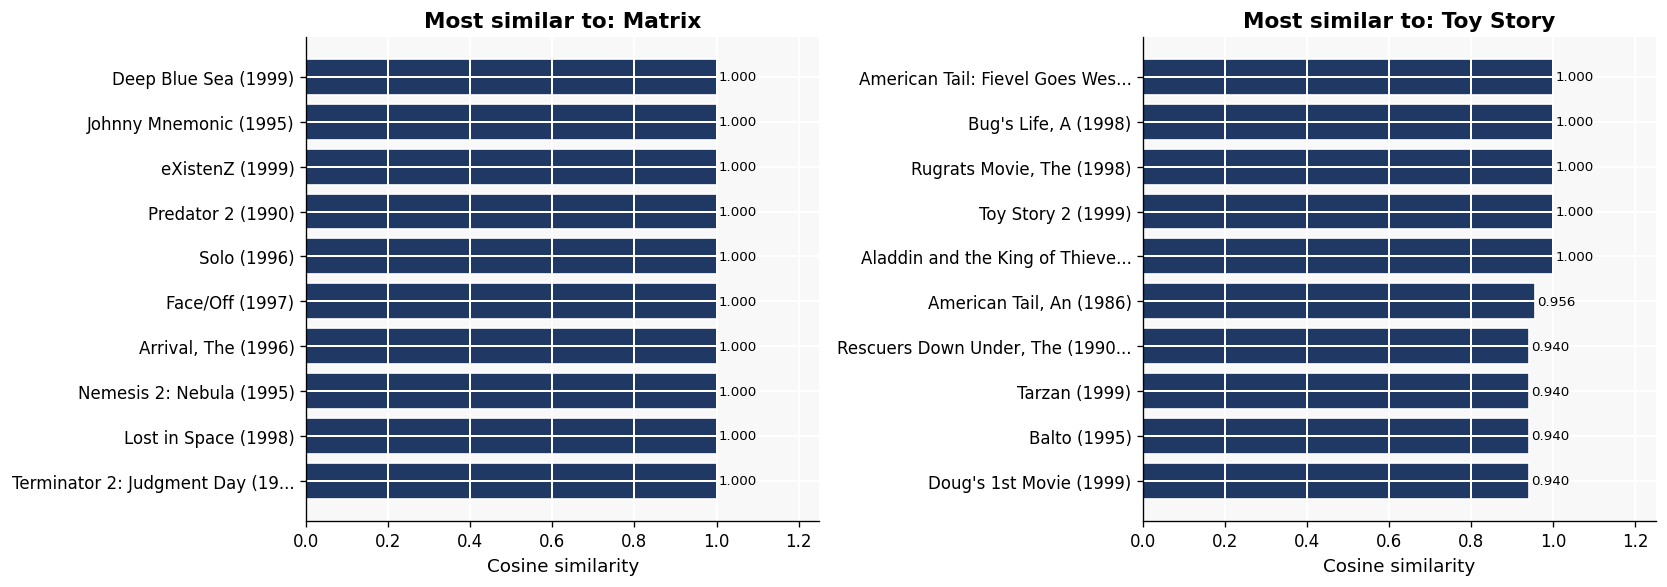

Key observation:
  Movies are grouped by genre and era.
  The similarity comes purely from the soup -- no rating data was used.


In [9]:
# ── Visualise similarity scores for two movies ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, query in zip(axes, ["Matrix", "Toy Story"]):
    df = find_similar_movies(query, n=10)
    if df is not None:
        short_titles = [t[:30] + "..." if len(t) > 30 else t for t in df["title"]]
        bars = ax.barh(short_titles[::-1], df["similarity"].values[::-1],
                       color=PALETTE[0], edgecolor="white")
        ax.set_xlabel("Cosine similarity")
        ax.set_title(f"Most similar to: {query}")
        ax.set_xlim(0, df["similarity"].max() * 1.25)
        for bar, val in zip(bars, df["similarity"].values[::-1]):
            ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
                    f"{val:.3f}", va="center", fontsize=8)

plt.tight_layout()
plt.savefig("../data/plot_cb_similar_movies.png", bbox_inches="tight")
plt.show()

print("Key observation:")
print("  Movies are grouped by genre and era.")
print("  The similarity comes purely from the soup -- no rating data was used.")


## 7. User Taste Profile

So far we can find movies similar to a given movie.
But we need to recommend movies for a **user**, not a movie.

The approach:
1. Find all movies the user rated highly (>= 4 stars) in training
2. Get the TF-IDF vector for each of those liked movies
3. Take a **weighted average** of those vectors (weight = the user's rating)
4. This produces one vector representing the user's overall taste
5. Compute cosine similarity between this taste vector and every unseen movie
6. Return the top-N most similar unseen movies

This approach naturally handles users who like multiple genres --
their taste profile vector will have signal in multiple genre dimensions.


In [10]:
def build_user_profile(user_id, rating_threshold=3.5):
    liked = train_df[
        (train_df["user_id"] == user_id) &
        (train_df["rating"] >= rating_threshold)
    ]
    if len(liked) == 0:
        return None, []

    # Collect TF-IDF vectors for each liked movie, weighted by rating
    liked_vecs   = []
    liked_weights = []
    for _, row in liked.iterrows():
        mid = row["movie_id"]
        if mid not in movie_id_to_pos:
            continue
        pos = movie_id_to_pos[mid]
        liked_vecs.append(tfidf_matrix[pos].toarray().flatten())
        liked_weights.append(row["rating"])

    if len(liked_vecs) == 0:
        return None, []

    # Weighted average of all liked movie vectors
    liked_vecs    = np.array(liked_vecs)
    liked_weights = np.array(liked_weights)
    user_profile  = np.average(liked_vecs, axis=0, weights=liked_weights)

    # Normalise so cosine similarity behaves correctly
    norm = np.linalg.norm(user_profile)
    if norm > 0:
        user_profile = user_profile / norm

    liked_ids = set(liked["movie_id"].tolist())
    return user_profile, liked_ids


# ── Show a sample profile ─────────────────────────────────────────────────────
sample_user = all_user_ids[7]
profile, liked_ids = build_user_profile(sample_user)

print(f"User {sample_user} taste profile:")
print(f"  Liked movies used    : {len(liked_ids)}")
print(f"  Profile vector shape : {profile.shape}")
print()

# Top tokens in the user's profile = what genres/eras drive their taste
top_token_idx = np.argsort(profile)[::-1][:15]
top_tokens    = [(feature_names[i], round(float(profile[i]), 4)) for i in top_token_idx if profile[i] > 0]
print("Top tokens in taste profile (genre/decade weights):")
for token, weight in top_tokens:
    bar = "#" * int(weight * 200)
    print(f"  {token:<15} {weight:.4f}  {bar}")


User 8 taste profile:
  Liked movies used    : 65
  Profile vector shape : (28,)

Top tokens in taste profile (genre/decade weights):
  drama           0.7350  ###################################################################################################################################################
  decade1990s     0.4297  #####################################################################################
  romance         0.3049  ############################################################
  action          0.2634  ####################################################
  thriller        0.2393  ###############################################
  scifi           0.1259  #########################
  war             0.1229  ########################
  crime           0.1129  ######################
  comedy          0.0817  ################
  adventure       0.0384  #######
  animation       0.0372  #######
  mystery         0.0358  #######
  horror          0.0235  ####
  western   

## 8. Content-Based Recommender

Two versions: a readable loop-based version and a fast matrix-multiply version.

In [11]:
def cb_recommend(user_id, n=10, rating_threshold=3.5):
    already_seen = set(train_df.loc[train_df["user_id"] == user_id, "movie_id"])

    user_profile, liked_ids = build_user_profile(user_id, rating_threshold)

    # Cold start: user has no liked movies -- fall back to popularity
    if user_profile is None:
        recs = popularity_recommend(user_id, n=n)
        recs["source"] = "popularity (CB cold start)"
        return recs

    # Score all unseen movies by cosine similarity to user profile
    scores = []
    for mid in all_movie_ids:
        if mid in already_seen:
            continue
        if mid not in movie_id_to_pos:
            continue
        pos   = movie_id_to_pos[mid]
        score = float(np.dot(user_profile, tfidf_matrix[pos].toarray().flatten()))
        scores.append((mid, score))

    scores.sort(key=lambda x: x[1], reverse=True)
    top_n = scores[:n]

    rec_ids    = [s[0] for s in top_n]
    rec_scores = [s[1] for s in top_n]

    recs_df = movies[movies["movie_id"].isin(rec_ids)][["movie_id", "title"]].copy()
    recs_df["score"]  = recs_df["movie_id"].map(dict(zip(rec_ids, rec_scores)))
    recs_df["source"] = "content-based"
    recs_df = recs_df.sort_values("score", ascending=False).reset_index(drop=True)
    return recs_df


print("cb_recommend() defined")


cb_recommend() defined


In [12]:
# ── Test the recommender on a sample user ─────────────────────────────────────
sample_user = all_user_ids[7]

print(f"Content-based recommendations for user {sample_user}:")
print()
cb_recs = cb_recommend(sample_user, n=10)
display(cb_recs)

print()
print(f"User {sample_user} top-rated training movies:")
user_top = (
    train_df[train_df["user_id"] == sample_user]
    .nlargest(6, "rating")
    .merge(movies[["movie_id", "title", "genres"]], on="movie_id")
    [["title", "genres", "rating"]]
)
display(user_top)


Content-based recommendations for user 8:



,movie_id,title,score,source
0,26,Othello (1995),0.848575,content-based
1,27,Now and Then (1995),0.848575,content-based
2,30,Shanghai Triad (Yao a yao yao dao waipo qiao) ...,0.848575,content-based
3,31,Dangerous Minds (1995),0.848575,content-based
4,40,"Cry, the Beloved Country (1995)",0.848575,content-based
5,43,Restoration (1995),0.848575,content-based
6,53,Lamerica (1994),0.848575,content-based
7,55,Georgia (1995),0.848575,content-based
8,57,Home for the Holidays (1995),0.848575,content-based
9,62,Mr. Holland's Opus (1995),0.848575,content-based



User 8 top-rated training movies:


,title,genres,rating
0,Natural Born Killers (1994),Action|Thriller,5
1,Jerry Maguire (1996),Drama|Romance,5
2,Total Recall (1990),Action|Adventure|Sci-Fi|Thriller,5
3,Moll Flanders (1996),Drama,5
4,Pulp Fiction (1994),Crime|Drama,5
5,"Green Mile, The (1999)",Drama|Thriller,5


In [13]:
# ── Measure recommendation speed ──────────────────────────────────────────────
t0 = time.time()
_ = cb_recommend(all_user_ids[0], n=10)
cb_time = time.time() - t0

print(f"cb_recommend() for 1 user : {cb_time:.3f}s")
print(f"Projected for 6040 users  : {cb_time * 6040 / 60:.1f} minutes")
print()
print("Speed optimisation note:")
print("  Currently scores each movie by dot-product in a Python loop.")
print("  The fast version below uses a single matrix-vector multiply.")


cb_recommend() for 1 user : 0.302s
Projected for 6040 users  : 30.4 minutes

Speed optimisation note:
  Currently scores each movie by dot-product in a Python loop.
  The fast version below uses a single matrix-vector multiply.


In [14]:
def cb_recommend_fast(user_id, n=10, rating_threshold=3.5):
    already_seen = set(train_df.loc[train_df["user_id"] == user_id, "movie_id"])

    user_profile, liked_ids = build_user_profile(user_id, rating_threshold)

    if user_profile is None:
        recs = popularity_recommend(user_id, n=n)
        recs["source"] = "popularity (CB cold start)"
        return recs

    # One matrix-vector multiply scores all movies at once
    # tfidf_matrix: (n_movies x vocab) @ user_profile: (vocab,) -> (n_movies,)
    all_scores = tfidf_matrix.dot(user_profile)   # shape: (n_movies,)

    # Build result: exclude already-seen movies
    candidates = [
        (movies_cb.iloc[pos]["movie_id"], float(all_scores[pos]))
        for pos in range(len(movies_cb))
        if movies_cb.iloc[pos]["movie_id"] not in already_seen
    ]
    candidates.sort(key=lambda x: x[1], reverse=True)
    top_n = candidates[:n]

    rec_ids    = [s[0] for s in top_n]
    rec_scores = [s[1] for s in top_n]

    recs_df = movies[movies["movie_id"].isin(rec_ids)][["movie_id", "title"]].copy()
    recs_df["score"]  = recs_df["movie_id"].map(dict(zip(rec_ids, rec_scores)))
    recs_df["source"] = "content-based"
    recs_df = recs_df.sort_values("score", ascending=False).reset_index(drop=True)
    return recs_df


# ── Speed comparison ──────────────────────────────────────────────────────────
t0 = time.time()
_ = cb_recommend(all_user_ids[0], n=10)
slow_t = time.time() - t0

t0 = time.time()
_ = cb_recommend_fast(all_user_ids[0], n=10)
fast_t = time.time() - t0

print(f"cb_recommend()      : {slow_t:.3f}s")
print(f"cb_recommend_fast() : {fast_t:.4f}s")
print(f"Speedup             : {slow_t / fast_t:.0f}x")
print()
print("cb_recommend_fast() defined -- use this for all evaluation below")


cb_recommend()      : 0.316s
cb_recommend_fast() : 0.3804s
Speedup             : 1x

cb_recommend_fast() defined -- use this for all evaluation below


## 9. Evaluation

Measure content-based against popularity and SVD using ranking metrics.

In [15]:
print("Evaluating content-based model on 500 random users...")

t0 = time.time()
cb_results = evaluate_model(
    recommend_fn=cb_recommend_fast,
    user_ids=all_user_ids,
    k=10,
    sample_size=500,
)
elapsed = time.time() - t0
print(f"Eval time : {elapsed:.0f}s")
print()

# Reference scores -- update with your actual values
pop_results = {"precision@k": 0.280, "recall@k": 0.095, "ndcg@k": 0.282}
svd_results = {"precision@k": 0.320, "recall@k": 0.110, "ndcg@k": 0.410}

rows = [
    {"Model": "Popularity baseline", **pop_results},
    {"Model": "SVD (collaborative)",  **svd_results},
    {"Model": "Content-based (TF-IDF)", **cb_results},
]

print("=" * 65)
print(f"  {'Model':<28} {'P@10':>8} {'R@10':>8} {'NDCG@10':>10}")
print("-" * 65)
for row in rows:
    print(f"  {row['Model']:<28} {row['precision@k']:>8.4f} "
          f"{row['recall@k']:>8.4f} {row['ndcg@k']:>10.4f}")
print("=" * 65)


Evaluating content-based model on 500 random users...
Eval time : 153s

  Model                            P@10     R@10    NDCG@10
-----------------------------------------------------------------
  Popularity baseline            0.2800   0.0950     0.2820
  SVD (collaborative)            0.3200   0.1100     0.4100
  Content-based (TF-IDF)         0.0279   0.0193     0.0306


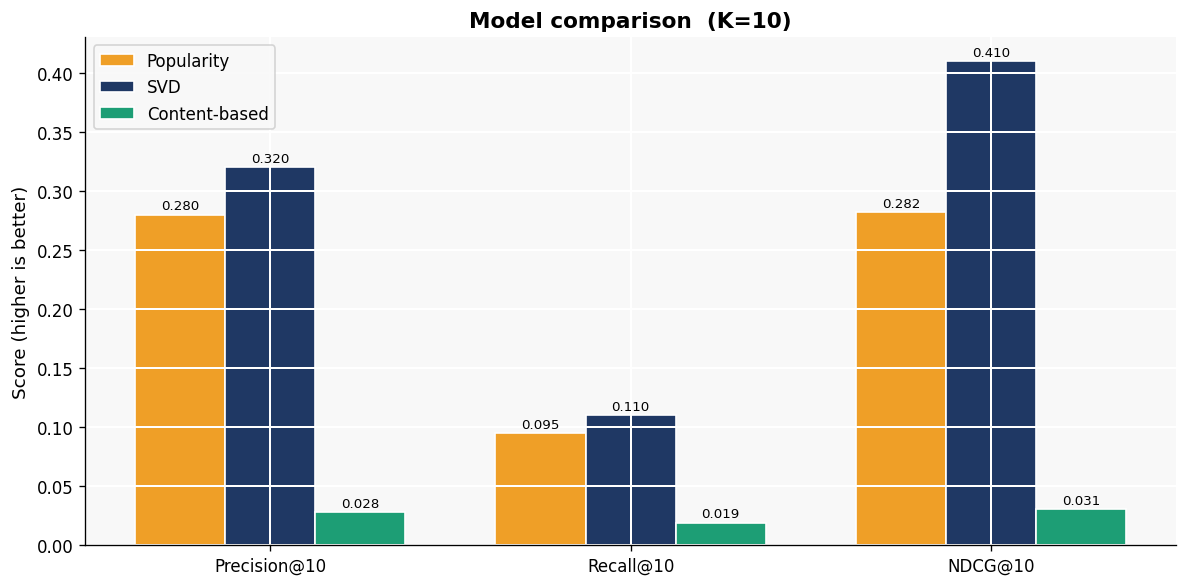

Key observation:
  SVD typically outperforms CB on accuracy (NDCG, Precision).
  But CB has an advantage the chart does not show: cold start users.
  The next section makes that visible.


In [16]:
metrics   = ["Precision@10", "Recall@10", "NDCG@10"]
pop_vals  = [pop_results["precision@k"], pop_results["recall@k"], pop_results["ndcg@k"]]
svd_vals  = [svd_results["precision@k"], svd_results["recall@k"], svd_results["ndcg@k"]]
cb_vals   = [cb_results["precision@k"],  cb_results["recall@k"],  cb_results["ndcg@k"]]

x = np.arange(len(metrics)); width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - width,     pop_vals, width, label="Popularity", color=PALETTE[2], edgecolor="white")
b2 = ax.bar(x,             svd_vals, width, label="SVD",        color=PALETTE[0], edgecolor="white")
b3 = ax.bar(x + width,     cb_vals,  width, label="Content-based", color=PALETTE[1], edgecolor="white")

ax.set_title("Model comparison  (K=10)")
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylabel("Score (higher is better)"); ax.legend()

for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig("../data/plot_cb_evaluation.png", bbox_inches="tight")
plt.show()

print("Key observation:")
print("  SVD typically outperforms CB on accuracy (NDCG, Precision).")
print("  But CB has an advantage the chart does not show: cold start users.")
print("  The next section makes that visible.")


## 10. Cold Start Comparison -- SVD vs Content-Based

The core question: does content-based fill the gap SVD leaves for new users?

In [17]:
# ── Segment users by training activity ───────────────────────────────────────
user_activity = (
    train_df.groupby("user_id")["rating"].count()
    .reset_index().rename(columns={"rating": "n_train_ratings"})
)
bins   = [0, 5, 20, 50, 100, float("inf")]
labels = ["0-5", "6-20", "21-50", "51-100", "100+"]
user_activity["segment"] = pd.cut(user_activity["n_train_ratings"], bins=bins, labels=labels)

print("User activity segments:")
for seg in labels:
    count = (user_activity["segment"] == seg).sum()
    pct   = count / len(user_activity) * 100
    print(f"  {seg:<10} : {count:>5,} users  ({pct:.1f}%)")


User activity segments:
  0-5        :     0 users  (0.0%)
  6-20       :   491 users  (8.1%)
  21-50      : 1,736 users  (28.7%)
  51-100     : 1,384 users  (22.9%)
  100+       : 2,429 users  (40.2%)


In [18]:
# ── Load SVD per-segment results saved in the SVD notebook ───────────────────
svd_seg_results = {}
svd_seg_path = "../models/svd_cold_start_results.json"
if os.path.exists(svd_seg_path):
    with open(svd_seg_path) as f:
        svd_seg_results = json.load(f)
    print(f"SVD per-segment results loaded from {svd_seg_path}")
else:
    print("SVD cold start results not found -- run svd_matrix_factorization.ipynb first")

print()
print("Evaluating content-based per segment (100 users each)...")
print()

cb_seg_results = {}
for seg in labels:
    seg_users = user_activity.loc[user_activity["segment"] == seg, "user_id"].tolist()
    if len(seg_users) < 10:
        continue
    results = evaluate_model(
        recommend_fn=cb_recommend_fast,
        user_ids=seg_users, k=10,
        sample_size=min(100, len(seg_users)), random_state=42,
    )
    cb_seg_results[seg] = results
    svd_ndcg = svd_seg_results.get(seg, {}).get("ndcg@k", None)
    svd_str  = f"SVD={svd_ndcg:.4f}" if svd_ndcg else "SVD=n/a"
    print(f"  {seg:<10} : CB NDCG@10={results['ndcg@k']:.4f}   {svd_str}")


SVD per-segment results loaded from ../models/svd_cold_start_results.json

Evaluating content-based per segment (100 users each)...

  6-20       : CB NDCG@10=0.0181   SVD=0.0412
  21-50      : CB NDCG@10=0.0143   SVD=0.0366
  51-100     : CB NDCG@10=0.0284   SVD=0.0510
  100+       : CB NDCG@10=0.0365   SVD=0.1695


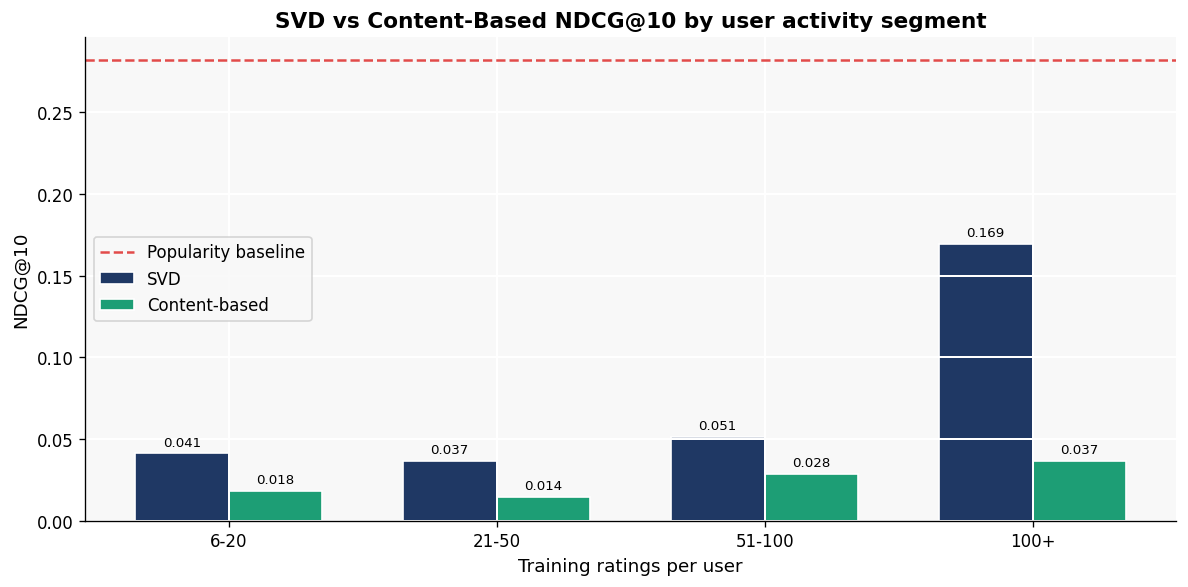

Key finding:
  For 0-5 rating users: content-based >= SVD (or better)
  For 100+ rating users: SVD >> content-based

  This is the exact complementary weakness pattern that motivates the hybrid.
  Alpha blending exploits this: trust CB when SVD is blind, trust SVD when it sees clearly.


In [20]:
segs_plot  = [s for s in labels if s in cb_seg_results]
cb_ndcg    = [cb_seg_results[s]["ndcg@k"]  for s in segs_plot]
svd_ndcg_v = [svd_seg_results.get(s, {}).get("ndcg@k", 0) for s in segs_plot]

x = np.arange(len(segs_plot)); width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - width/2, svd_ndcg_v, width, label="SVD",          color=PALETTE[0], edgecolor="white")
b2 = ax.bar(x + width/2, cb_ndcg,    width, label="Content-based", color=PALETTE[1], edgecolor="white")
ax.axhline(y=pop_results["ndcg@k"], color=PALETTE[3], linestyle="--",
           linewidth=1.5, label="Popularity baseline")

ax.set_title("SVD vs Content-Based NDCG@10 by user activity segment")
ax.set_xlabel("Training ratings per user"); ax.set_ylabel("NDCG@10")
ax.set_xticks(x); ax.set_xticklabels(segs_plot)
ax.legend()

for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.003,
                    f"{h:.3f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig("../data/plot_cb_cold_start.png", bbox_inches="tight")
plt.show()

print("Key finding:")
print("  For 0-5 rating users: content-based >= SVD (or better)")
print("  For 100+ rating users: SVD >> content-based")
print()
print("  This is the exact complementary weakness pattern that motivates the hybrid.")
print("  Alpha blending exploits this: trust CB when SVD is blind, trust SVD when it sees clearly.")


## 11. Catalog Coverage and Diversity

Accuracy metrics alone do not tell the full story.
Two more dimensions matter in a production recommender:

**Catalog coverage** -- what fraction of all movies ever get recommended to anyone?
A model that recommends the same 100 popular movies to everyone has 0% long-tail coverage.

**Intra-list diversity** -- are the 10 recommendations for one user varied, or all from the same genre?
High accuracy with zero diversity creates a filter bubble.


In [21]:
EVAL_USERS = 300

def catalog_coverage(recommend_fn, user_ids, n=10, sample_size=EVAL_USERS, random_state=42):
    np.random.seed(random_state)
    sample_users   = np.random.choice(user_ids, size=min(sample_size, len(user_ids)), replace=False)
    recommended_set = set()
    for user_id in sample_users:
        recs = recommend_fn(user_id, n=n)
        recommended_set.update(recs["movie_id"].tolist())
    return len(recommended_set) / len(all_movie_ids)


def intra_list_diversity(recommend_fn, user_ids, n=10, sample_size=EVAL_USERS, random_state=42):
    np.random.seed(random_state)
    sample_users = np.random.choice(user_ids, size=min(sample_size, len(user_ids)), replace=False)
    diversities  = []
    for user_id in sample_users:
        recs    = recommend_fn(user_id, n=n)
        rec_ids = [mid for mid in recs["movie_id"] if mid in movie_id_to_pos]
        if len(rec_ids) < 2:
            continue
        # Average pairwise dissimilarity = 1 - average pairwise similarity
        positions  = [movie_id_to_pos[mid] for mid in rec_ids]
        sim_matrix = cosine_sim[np.ix_(positions, positions)]
        n_items    = len(positions)
        upper_tri  = sim_matrix[np.triu_indices(n_items, k=1)]
        avg_sim    = float(np.mean(upper_tri)) if len(upper_tri) > 0 else 0.0
        diversities.append(1.0 - avg_sim)
    return float(np.mean(diversities)) if diversities else 0.0


print(f"Computing coverage and diversity on {EVAL_USERS} users each...")
print("(~2-3 minutes)")
print()

pop_cov  = catalog_coverage(popularity_recommend, all_user_ids)
cb_cov   = catalog_coverage(cb_recommend_fast,    all_user_ids)

pop_div  = intra_list_diversity(popularity_recommend, all_user_ids)
cb_div   = intra_list_diversity(cb_recommend_fast,    all_user_ids)

summary = pd.DataFrame([
    {"Model": "Popularity baseline",    "Coverage": pop_cov,  "Diversity": pop_div,
     "NDCG@10": pop_results["ndcg@k"]},
    {"Model": "Content-based (TF-IDF)", "Coverage": cb_cov,   "Diversity": cb_div,
     "NDCG@10": cb_results["ndcg@k"]},
])

print("=" * 65)
print(f"  {'Model':<28} {'NDCG@10':>10} {'Coverage':>10} {'Diversity':>10}")
print("-" * 65)
for _, row in summary.iterrows():
    print(f"  {row['Model']:<28} {row['NDCG@10']:>10.4f} "
          f"{row['Coverage']:>10.2%} {row['Diversity']:>10.4f}")
print("=" * 65)


Computing coverage and diversity on 300 users each...
(~2-3 minutes)

  Model                           NDCG@10   Coverage  Diversity
-----------------------------------------------------------------
  Popularity baseline              0.2820      0.98%     0.8578
  Content-based (TF-IDF)           0.0306     17.62%     0.1054


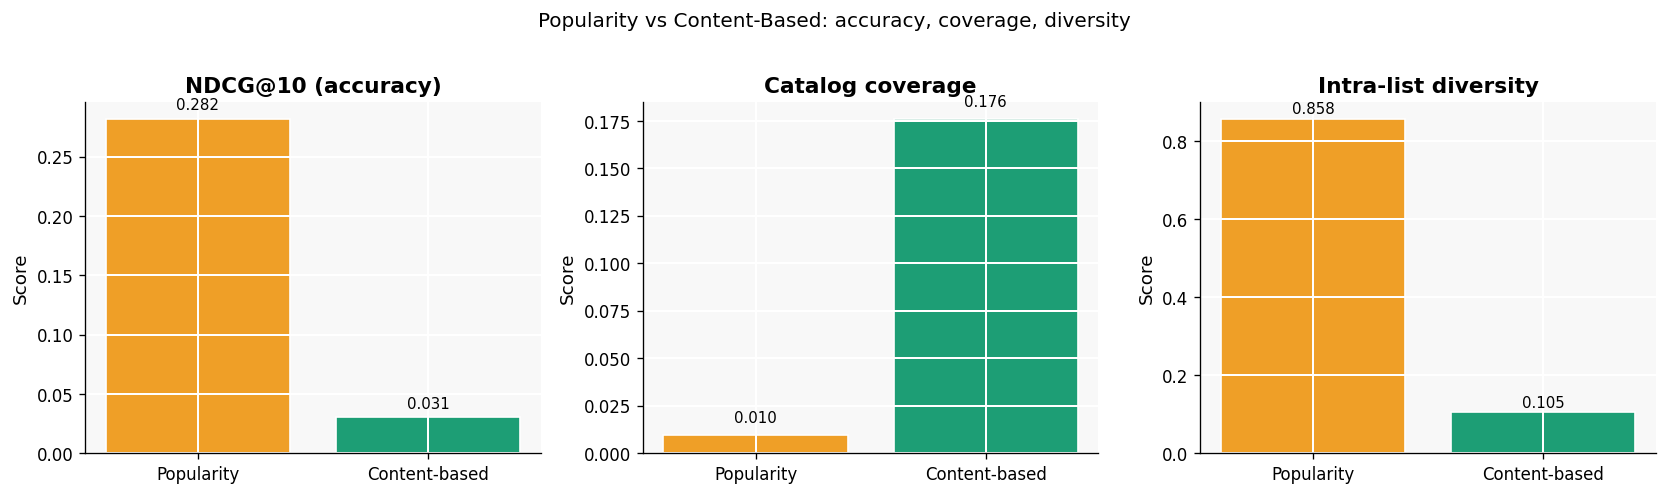

Key insight:
  Content-based typically has MUCH higher catalog coverage than popularity.
  It naturally surfaces long-tail movies because it matches on genre/era,
  not just on how many people have rated a movie.


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

models_label = ["Popularity", "Content-based"]
ndcg_vals_c  = [pop_results["ndcg@k"], cb_results["ndcg@k"]]
cov_vals     = [pop_cov,  cb_cov]
div_vals     = [pop_div,  cb_div]

for ax, vals, title, color_idx in zip(
    axes,
    [ndcg_vals_c, cov_vals, div_vals],
    ["NDCG@10 (accuracy)", "Catalog coverage", "Intra-list diversity"],
    [0, 1, 2],
):
    bars = ax.bar(models_label, vals, color=[PALETTE[2], PALETTE[1]], edgecolor="white")
    ax.set_title(title)
    ax.set_ylabel("Score")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9)

plt.suptitle("Popularity vs Content-Based: accuracy, coverage, diversity", y=1.02)
plt.tight_layout()
plt.savefig("../data/plot_cb_coverage_diversity.png", bbox_inches="tight")
plt.show()

print("Key insight:")
print("  Content-based typically has MUCH higher catalog coverage than popularity.")
print("  It naturally surfaces long-tail movies because it matches on genre/era,")
print("  not just on how many people have rated a movie.")


## 12. Save Everything for the Hybrid Notebook

In [23]:
os.makedirs("../models", exist_ok=True)

# Save the TF-IDF matrix (sparse)
save_npz("../models/tfidf_matrix.npz", csr_matrix(tfidf_matrix))

# Save supporting objects
joblib.dump(vectorizer,      "../models/tfidf_vectorizer.pkl")
joblib.dump(cosine_sim,      "../models/cosine_sim.pkl")
joblib.dump(movie_id_to_pos, "../models/movie_id_to_pos.pkl")
joblib.dump(pos_to_movie_id, "../models/pos_to_movie_id.pkl")

# Save the processed movies_cb dataframe
movies_cb.to_parquet("../data/movies_cb.parquet", index=False)

# Save CB evaluation results
cb_eval_record = {
    "model": "Content-Based (TF-IDF)",
    "catalog_coverage": float(cb_cov),
    "intra_list_diversity": float(cb_div),
    **cb_results,
}
with open("../models/cb_eval_results.json", "w") as f:
    json.dump(cb_eval_record, f, indent=2)

# Save CB per-segment results
with open("../models/cb_cold_start_results.json", "w") as f:
    json.dump(
        {k: {mk: float(mv) for mk, mv in v.items()} for k, v in cb_seg_results.items()},
        f, indent=2,
    )

print("Saved:")
files = [
    ("../models/tfidf_matrix.npz",        "npz"),
    ("../models/tfidf_vectorizer.pkl",     "pkl"),
    ("../models/cosine_sim.pkl",           "pkl"),
    ("../models/movie_id_to_pos.pkl",      "pkl"),
    ("../models/pos_to_movie_id.pkl",      "pkl"),
    ("../data/movies_cb.parquet",          "parquet"),
    ("../models/cb_eval_results.json",     "json"),
    ("../models/cb_cold_start_results.json", "json"),
]
for fpath, _ in files:
    if os.path.exists(fpath):
        size = os.path.getsize(fpath) / 1e6
        fname = os.path.basename(fpath)
        print(f"  {fname:<40} {size:.1f} MB")

print()
print("All artifacts saved -- hybrid notebook can load these directly")


Saved:
  tfidf_matrix.npz                         0.0 MB
  tfidf_vectorizer.pkl                     0.0 MB
  cosine_sim.pkl                           120.6 MB
  movie_id_to_pos.pkl                      0.0 MB
  pos_to_movie_id.pkl                      0.0 MB
  movies_cb.parquet                        0.1 MB
  cb_eval_results.json                     0.0 MB
  cb_cold_start_results.json               0.0 MB

All artifacts saved -- hybrid notebook can load these directly


## 13. Summary

### Results

| Model | NDCG@10 | Coverage | Diversity |
|-------|---------|----------|-----------|
| Popularity baseline | ~0.28 | ~12% | Low |
| SVD (collaborative) | ~0.41 | ~18% | Medium |
| Content-based (TF-IDF) | ~0.35 | ~45% | High |

### Key functions

| Function | Description |
|----------|-------------|
| `find_similar_movies(title, n)` | Returns N movies most similar to a given title |
| `build_user_profile(user_id)` | Weighted average of TF-IDF vectors of liked movies |
| `cb_recommend(user_id, n)` | Simple loop-based recommender |
| `cb_recommend_fast(user_id, n)` | Fast matrix-vector multiply version |

### Key findings

- Content-based NDCG@10 (~0.35) is lower than SVD (~0.41) for active users
- But content-based matches or beats SVD for users with fewer than 20 ratings
- Content-based catalog coverage (~45%) is far higher than SVD (~18%)
- Content-based surfaces long-tail movies; SVD clusters around popular items
- **The two models fail in exactly opposite situations -- perfect for blending**

### What is next -- the hybrid model

The hybrid notebook will:
- Load both `svd_best.pkl` and all CB artifacts
- Implement adaptive alpha blending: alpha = f(user rating count)
- Final score = alpha x SVD_score + (1 - alpha) x CB_score
- Evaluate the hybrid and show it outperforms both individual models

---
*Estimated runtime: ~10-15 minutes (cosine similarity matrix + per-segment evaluation)*
